

# **Question 1**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("hepatitis_A.csv")

In [3]:
# Drop rows with any missing values
df_clean = df.dropna()

In [4]:
# Select relevant features and target
features = ['SEX', 'Age_Quartile', 'STEROID', 'FATIGUE', 'MALAISE']
target = 'Class'
X = df_clean[features]
y = df_clean[target]

In [5]:
# Encode categorical feature (Age_Quartile)
X = pd.get_dummies(X, columns=['Age_Quartile'], drop_first=True)

In [6]:
# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
# Train a decision tree classifier using entropy (C5.0-like)
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [8]:
# Make predictions and evaluate accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7647


In [9]:
# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           1       0.12      0.50      0.20         2
           2       0.96      0.78      0.86        32

    accuracy                           0.76        34
   macro avg       0.54      0.64      0.53        34
weighted avg       0.91      0.76      0.82        34



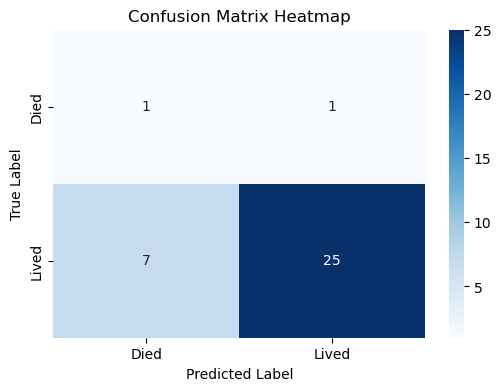

In [10]:
# Confusion Matrix Heatmap
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died', 'Lived'], yticklabels=['Died', 'Lived'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

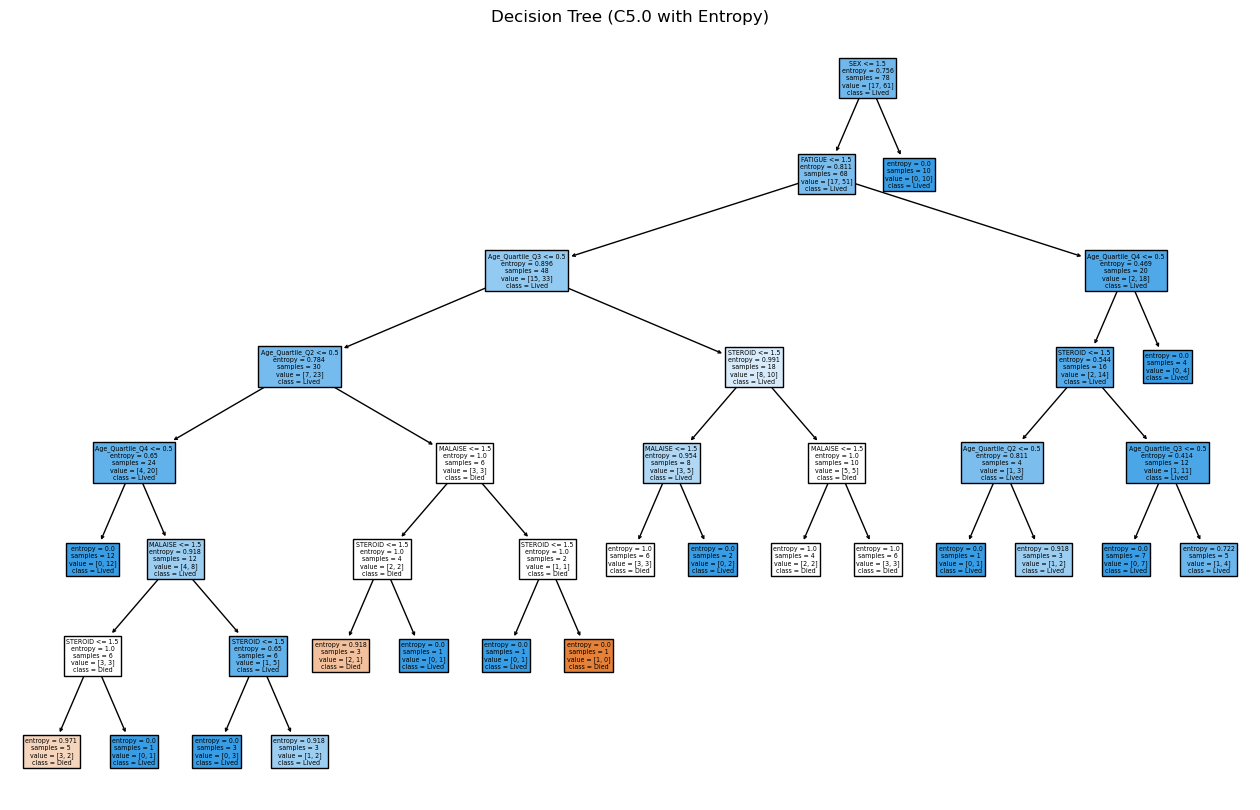

In [11]:
# Visualize the Decision Tree
plt.figure(figsize=(16, 10))
plot_tree(clf, feature_names=X.columns, class_names=['Died', 'Lived'], filled=True)
plt.title("Decision Tree (C5.0 with Entropy)")
plt.show()



**What is the accuracy of your model?**

The Decision Tree model achieved an **accuracy of 76.47%** on the test set after training on 70% of the dataset.

**Is this a good model? Why or why not?**

Yes, this is a reasonably good model. An accuracy of over 76% indicates that the model is able to make meaningful predictions using only a limited set of input features. The decision tree provides interpretable rules and captures non-linear relationships in the data. However, the dataset is relatively small, and the model was evaluated on a single train-test split without cross-validation, which may limit its generalizability. Additionally, the performance could be further improved by incorporating more features or using ensemble techniques.


